# ___Summaries of hOUwie model fits___
-------------------------------

In [1]:
print(R.version$version.string)

[1] "R version 4.5.3 (2026-03-11 ucrt)"


In [2]:
suppressPackageStartupMessages({
    library("ape")
    library("phytools")
    library("corHMM")
    library("OUwie")
    library("ggplot2")
})

source("../helpers.R")

In [3]:
options(repr.plot.width = 30, repr.plot.height = 12)

In [ ]:
# find out the AIC and AICc of all the models

# OUwie::getModelAvgParams()
# type - one of AIC, BIC, or AICc for use during evaluation of relative model fit.
# AICc (small sample size corrected AIC) is the best option for datasets with a few number of species.
# force - a boolean indicating whether to force potentially failed model fits to be included in the model averaging.

# look up to see what the BIC stuff is about https://www.rdocumentation.org/packages/AICcmodavg/versions/2.3-4/topics/bictabCustom
# AIC vs BIC https://fiveable.me/bayesian-statistics/unit-11/bayesian-information-criterion/study-guide/o3iS2biLgz7mcyuv

# ___`hOUwie`___
------------------------------

In [ ]:
# the following are model fits for data that had
# - log transformed RD & SRL values
# - 5 mycorrhizal states (no ErM or OrM)
# - 995 unique plant species from FRED 3.0
# - mycorrhizal state information from FungalRoot
# - nsims set to 100 when fitting hOUwie models

In [6]:
length(unique(read.csv("../../data/chapter2/FREDv3subset/collab_fineroots_log_995_species_means_5states_name_matched_with_phylogeny.csv")$binominal)) # 995 species

[1] 995

In [21]:
dir("./../../data/chapter2/rdata/parallel/", recursive = FALSE, full.names = TRUE) # serialized model folders

[1] "./../../data/chapter2/rdata/parallel/LOG_RD_995SP_100SIMS" 
[2] "./../../data/chapter2/rdata/parallel/LOG_SRL_995SP_100SIMS"

In [4]:
# get all the 995 species 5 states models, compute the averages and serialize them in a .csv file

capture.output(avg_CD_logRD_994sp_5 <- OUwie::getModelAvgParams(readallRds(dirpath = "../rdata/parallel/LOG_RD_994SP_5/", cd = TRUE, regstrip = "_CD.Rds"), type = "AICc", force = FALSE), file = nullfile())
capture.output(avg_CID_logRD_994sp_5 <- OUwie::getModelAvgParams(readallRds(dirpath = "../rdata/parallel/LOG_RD_994SP_5/", cd = FALSE, regstrip = "_CID.Rds"), type = "AICc", force = FALSE), file = nullfile())
capture.output(avg_CD_logSRL_994sp_5 <- OUwie::getModelAvgParams(readallRds(dirpath = "../rdata/parallel/LOG_SRL_994SP_5/", cd = TRUE, regstrip = "_CD.Rds"), type = "AICc", force = FALSE), file = nullfile())
capture.output(avg_CID_logSRL_994sp_5 <- OUwie::getModelAvgParams(readallRds(dirpath = "../rdata/parallel/LOG_SRL_994SP_5/", cd = FALSE, regstrip = "_CID.Rds"), type = "AICc", force = FALSE), file = nullfile())

In [38]:
houwie_summary <- rbind(
    cbind(binominal = rownames(avg_CD_logRD_994sp_5), avg_CD_logRD_994sp_5, is_cd = TRUE, trait = "logRD"),
    cbind(binominal = rownames(avg_CID_logRD_994sp_5), avg_CID_logRD_994sp_5, is_cd = FALSE, trait = "logRD"),
    cbind(binominal = rownames(avg_CD_logSRL_994sp_5), avg_CD_logSRL_994sp_5, is_cd = TRUE, trait = "logSRL"),
    cbind(binominal = rownames(avg_CID_logSRL_994sp_5), avg_CID_logSRL_994sp_5, is_cd = FALSE, trait = "logSRL")
)
rownames(houwie_summary) <- NULL

In [40]:
write.csv(houwie_summary, file = "./994species_5states_model_averages.csv", row.names = FALSE)

In [44]:
rd_cd_table <- OUwie::getModelTable(readallRds(dirpath = "../rdata/parallel/LOG_RD_994SP_5/", cd = TRUE, regstrip = "_CD.Rds"), type = "AICc")
rd_cid_table <- OUwie::getModelTable(readallRds(dirpath = "../rdata/parallel/LOG_RD_994SP_5/", cd = FALSE, regstrip = "_CID.Rds"), type = "AICc")

In [60]:
srl_cd_table <- OUwie::getModelTable(readallRds(dirpath = "../rdata/parallel/LOG_SRL_994SP_5/", cd = TRUE, regstrip = "_CD.Rds"), type = "AICc")
srl_cid_table <- OUwie::getModelTable(readallRds(dirpath = "../rdata/parallel/LOG_SRL_994SP_5/", cd = FALSE, regstrip = "_CID.Rds"), type = "AICc")

In [46]:
NECESSARY_ESTIMATES <- c("lnLik", "AICc")

In [62]:
write.csv(rd_cid_table[, NECESSARY_ESTIMATES], file = "./houwie_fits_rd_5states_994sp_cid.csv")
write.csv(rd_cd_table[, NECESSARY_ESTIMATES], file = "./houwie_fits_rd_5states_994sp_cd.csv")

In [63]:
write.csv(srl_cid_table[, NECESSARY_ESTIMATES], file = "./houwie_fits_srl_5states_994sp_cid.csv")
write.csv(srl_cd_table[, NECESSARY_ESTIMATES], file = "./houwie_fits_srl_5states_994sp_cd.csv")

In [4]:
# model fitting with 995 plant species and mycorrhizal state data from FungalRoot, log transformed RD & SRL data from FRED 3.0
# 5 mycorrhizal states
# with nsims = 100

In [5]:
CD_log_RD_995sp_100 <- readallRds(dirpath = "./../../data/chapter2/rdata/parallel/LOG_RD_995SP_100SIMS/", cd = TRUE, regstrip = "_CD.Rds")
CID_log_RD_995sp_100 <- readallRds(dirpath = "./../../data/chapter2/rdata/parallel/LOG_RD_995SP_100SIMS/", cd = FALSE, regstrip = "_CID.Rds")

In [12]:
OUwie::getModelTable(CD_log_RD_995sp_100, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUMF00679,27,-837.7815,-222.4381,-610.7957,1731.127,14.5409887,3.748617e-04
ARDOUMAF00679,31,-1240.7399,-224.6911,-1009.8106,2545.540,828.9543658,5.324186e-181
ARDOUMVF00679,31,-875.8786,-222.4858,-648.7782,1815.817,99.2318326,1.525766e-22
ARDOUMVAF00679,35,-1214.4508,-225.2339,-984.6957,2501.529,784.9436965,1.918884e-171
EROUMF00679,8,-1307.4927,-235.9841,-1065.8242,2631.131,914.5458396,1.381341e-199
EROUMAF00679,12,-1254.1331,-235.9806,-1017.0206,2532.584,815.9983010,3.464391e-178
EROUMVF00679,12,-1238.7481,-235.9414,-999.0268,2501.814,785.2283279,1.664339e-171
EROUMVAF00679,16,-1221.0799,-235.9916,-980.3370,2474.716,758.1305515,1.274821e-165
SYMOUMF00679,17,-841.1358,-225.8393,-610.8337,1716.898,0.3124422,4.608511e-01


Using tip_state as id variables



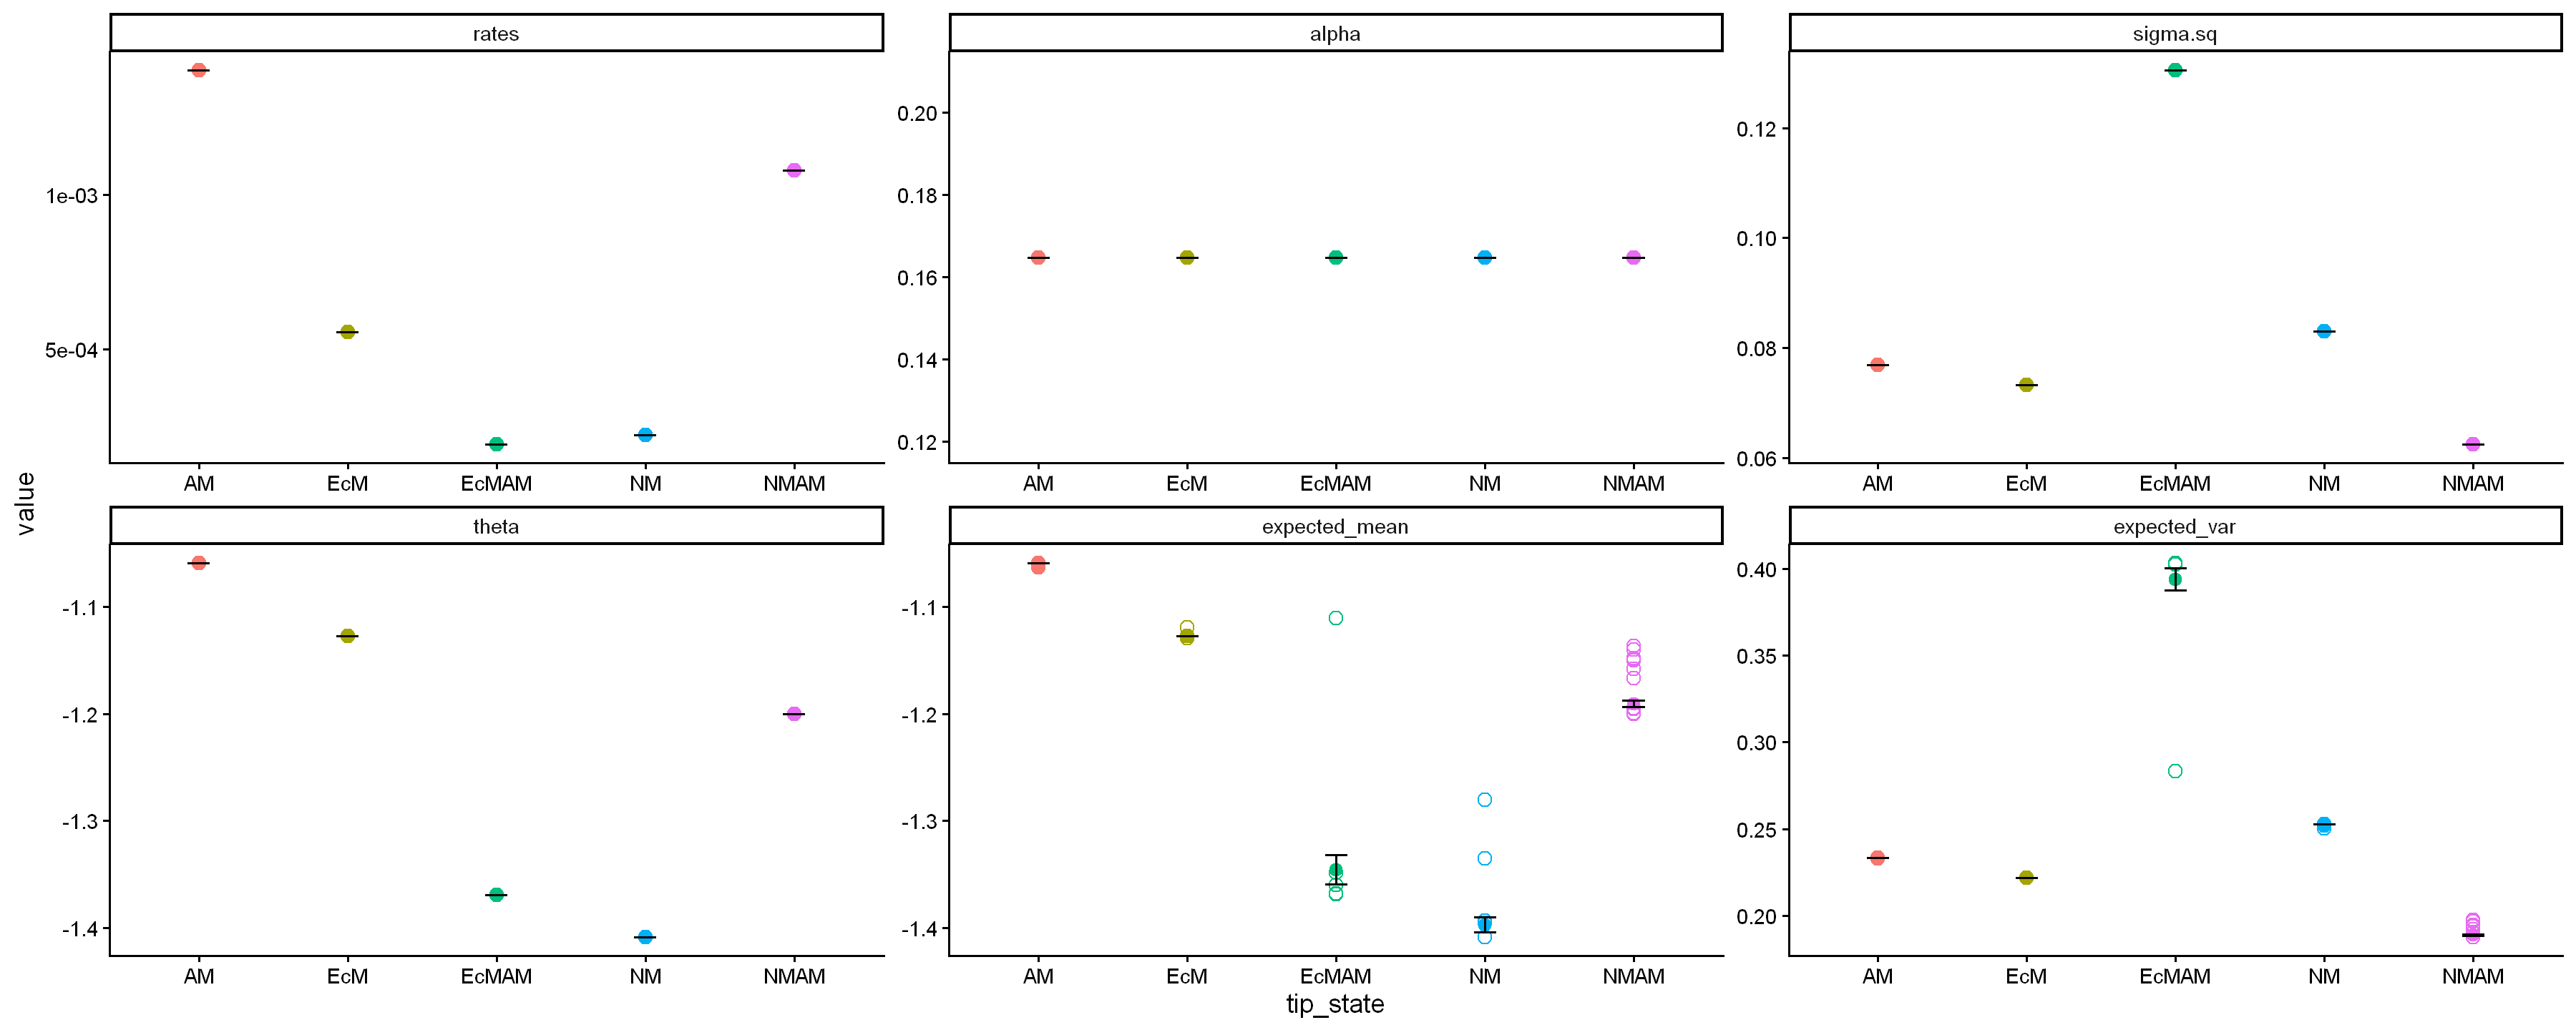

In [9]:
capture.output(df <- OUwie::getModelAvgParams(CD_log_RD_995sp_100, type = "AICc", force = FALSE), file = nullfile())
plot_df <- reshape2::melt(df)

plt <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) +
    theme(legend.position = "none") +
    facet_wrap(~variable, scales = "free")
plot(plt)

In [13]:
OUwie::getModelTable(CID_log_RD_995sp_100, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUMF00679,46,-8.660587e+02,-244.8339,-6.175052e+02,1.828679e+03,18253609577,0
ARDOUMAF00679,47,-1.297129e+03,-245.0929,-1.054712e+03,2.693023e+03,18253610441,0
ARDOUMVF00679,47,-1.285349e+03,-244.7591,-1.039078e+03,2.669462e+03,18253610417,0
ARDOUMVAF00679,48,-1.277052e+03,-245.2749,-1.044505e+03,2.655076e+03,18253610403,0
EROUMF00679,8,-8.584728e+02,-236.2650,-6.178687e+02,1.733092e+03,18253609481,0
EROUMAF00679,9,4.294540e+09,-236.6196,-8.320778e+03,-8.589081e+09,9664527211,0
EROUMVF00679,9,-8.728444e+02,-236.0431,-6.322679e+02,1.763872e+03,18253609512,0
EROUMVAF00679,10,9.126804e+09,-242.6438,8.589933e+09,-1.825361e+10,0,1
SYMOUMF00679,26,-8.853430e+02,-248.2156,-1.078624e+03,1.824136e+03,18253609572,0


Using tip_state as id variables



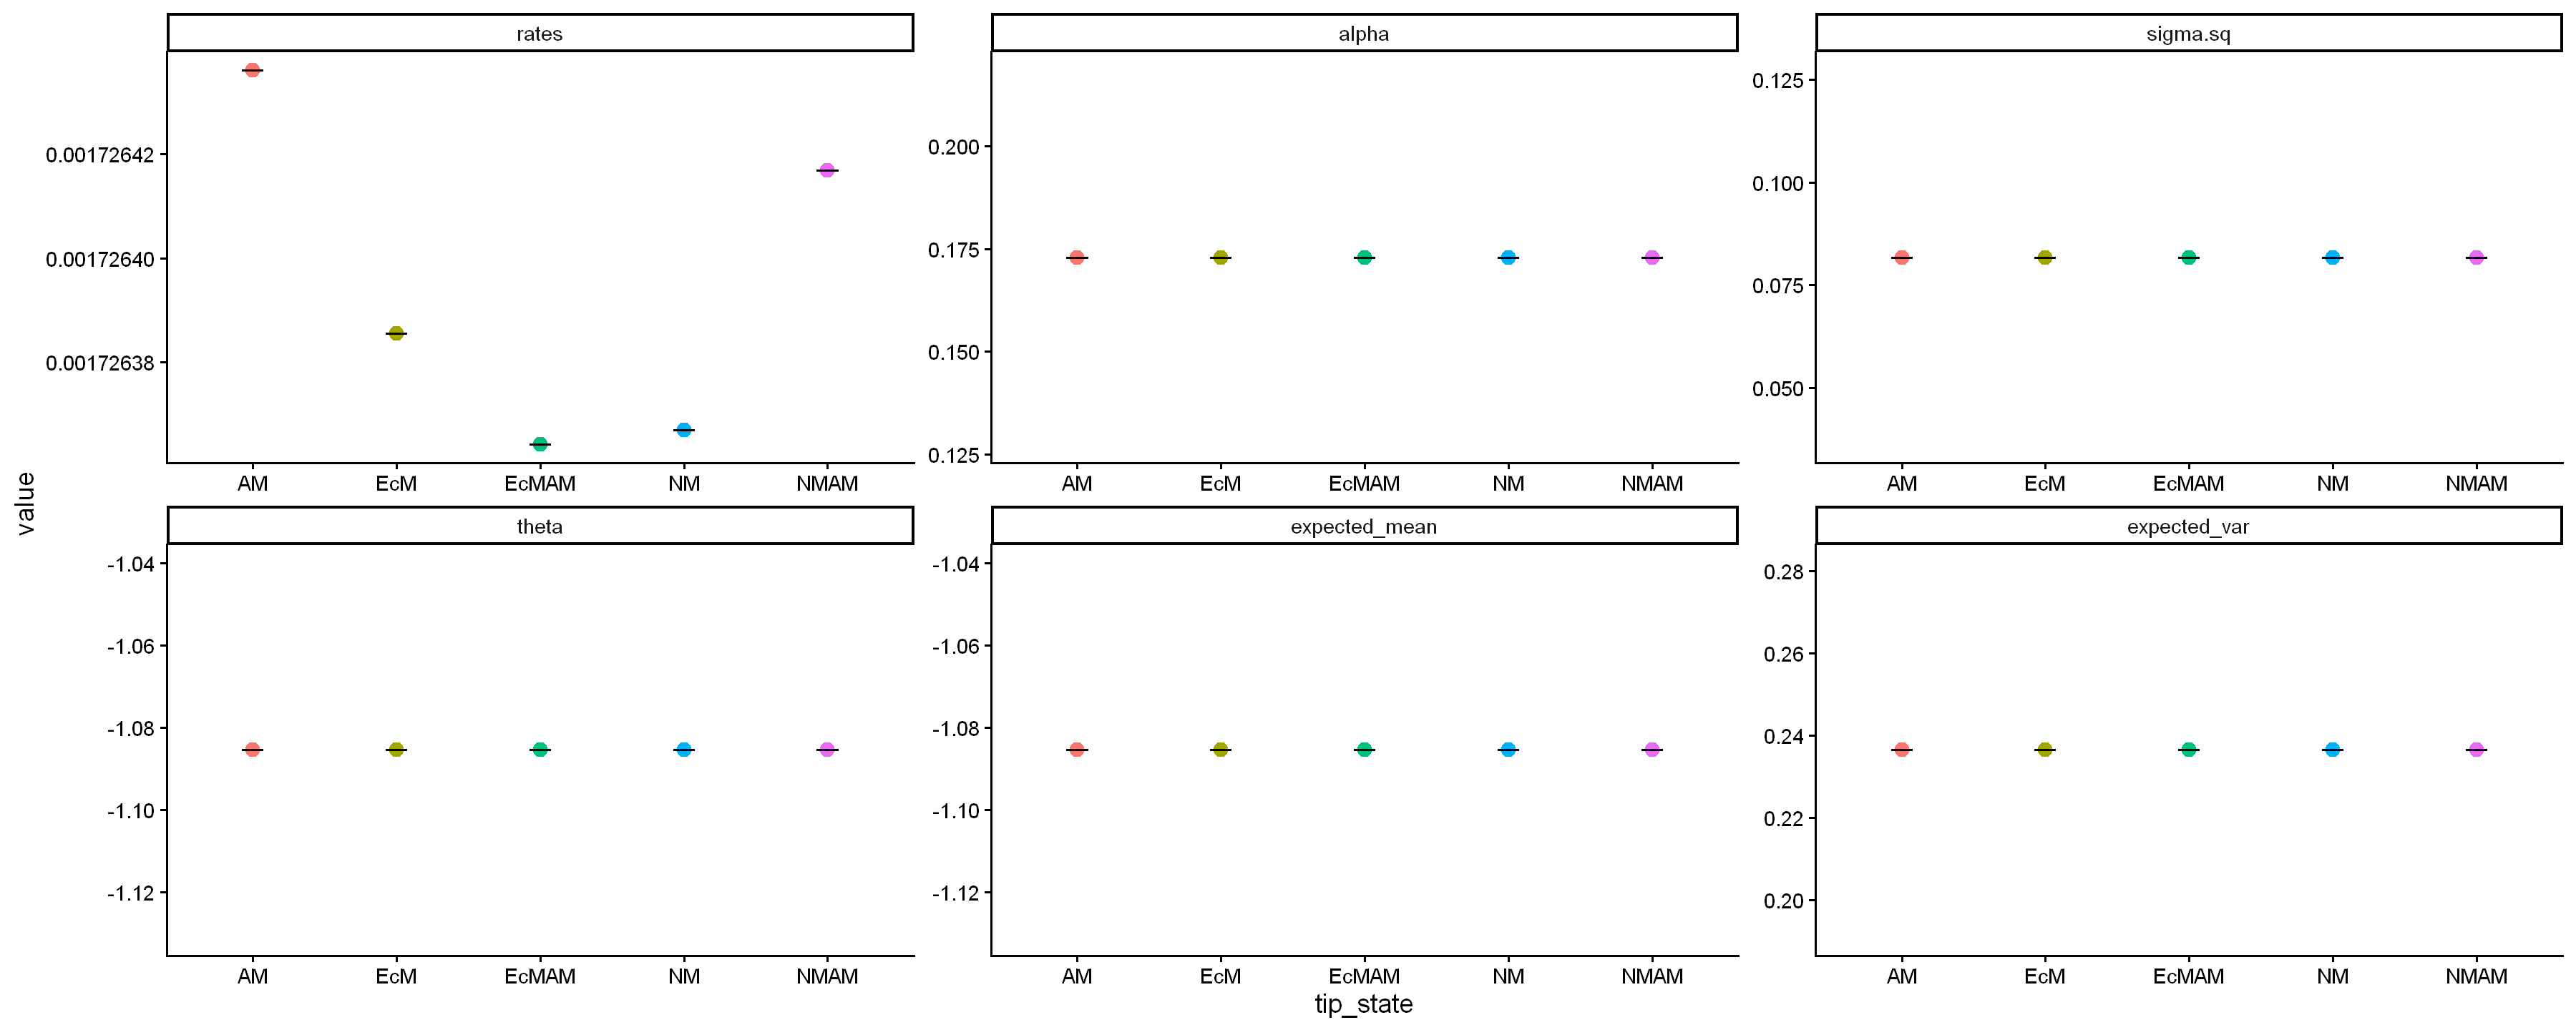

In [10]:
capture.output(df <- OUwie::getModelAvgParams(CID_log_RD_995sp_100, type = "AICc", force = FALSE), file = nullfile())
plot_df <- reshape2::melt(df)

plt <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) +
    theme(legend.position = "none") +
    facet_wrap(~variable, scales = "free")
plot(plt)